In [1]:
import numpy as np

In [2]:
# Basic Python Concepts:
# Variables
a = 0
# Terminal Output
print(a)
# Container datatypes and for loops
example_list = [0, 4, "hello"]
for value in example_list:
    print(value)
# Functions
def power_of_two(x):
    return 2**x
print(power_of_two(a))

0
0
4
hello
1


In [3]:
# Basic Vector Algebra
# Numpy array types
vector = np.array([0, 0, 1])
print(vector)
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 10]])
print(matrix)
# Matrix multiplication
print(matrix@vector)
# Inversion
print(np.linalg.inv(matrix)@vector)
# More efficient solvers...
print(np.linalg.solve(matrix, vector))
# Tensor algebra and Einstein's sum convention
fourth_order = np.ones((3,3,3,3))
print(np.einsum("ijkl,kl", fourth_order, matrix, optimize="optimal"))

[0 0 1]
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8 10]]
[ 3  6 10]
[ 1. -2.  1.]
[ 1. -2.  1.]
[[46. 46. 46.]
 [46. 46. 46.]
 [46. 46. 46.]]


In [4]:
b = 10**-8
c = 10**8
print((b+c)-c)

1.4901161193847656e-08


In [5]:
# Some microstructure concepts. First, consider a random two-phase microstructure on an equidistant 2D grid:
np.random.seed = 0
rand_vector = np.random.randint(low=0, high=2, size=100)
phase_grid = rand_vector.reshape((10, 10))
print(phase_grid)

[[0 0 0 0 0 1 0 1 1 0]
 [1 1 0 1 0 0 0 1 0 0]
 [0 0 0 0 1 0 1 1 0 1]
 [1 1 1 1 0 1 1 0 0 0]
 [1 1 1 1 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 1 1 0 0]
 [1 1 1 0 0 1 0 1 1 0]
 [0 0 0 1 0 0 0 1 1 1]
 [0 0 1 0 1 1 0 0 1 0]]


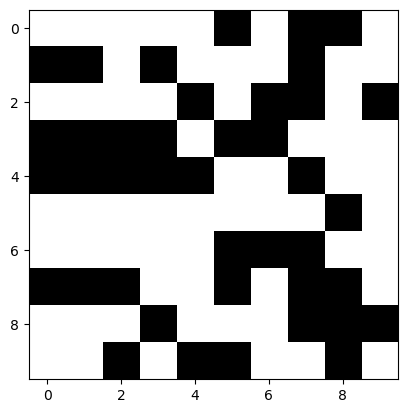

In [6]:
# But printing this is ugly.
import matplotlib.pyplot as plt
import matplotlib.cm
%matplotlib inline
plt.imshow(phase_grid, cmap=matplotlib.cm.Greys)
plt.show()

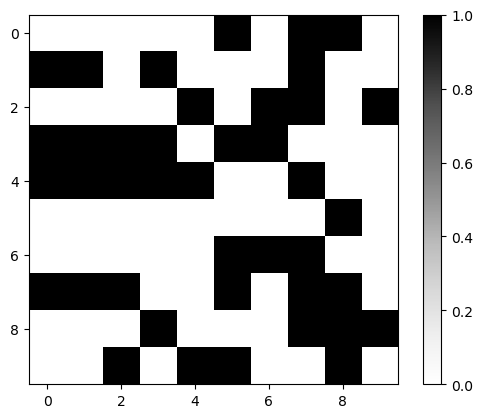

In [7]:
# or even...
def plot(grid_2D):
    plt.clf()
    plt.imshow(grid_2D, vmin=0, vmax=1, interpolation='nearest', cmap=matplotlib.cm.Greys)
    plt.colorbar()
    plt.show()
plot(phase_grid)

Indicator Phase 0:


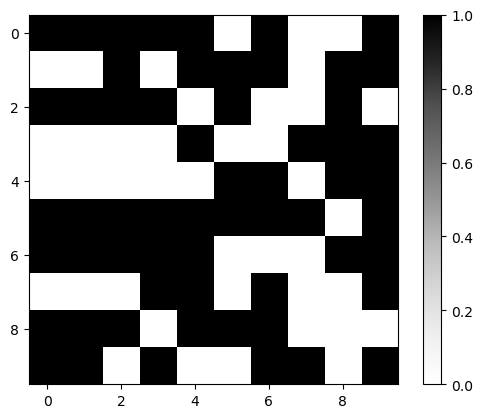

Indicator Phase 1:


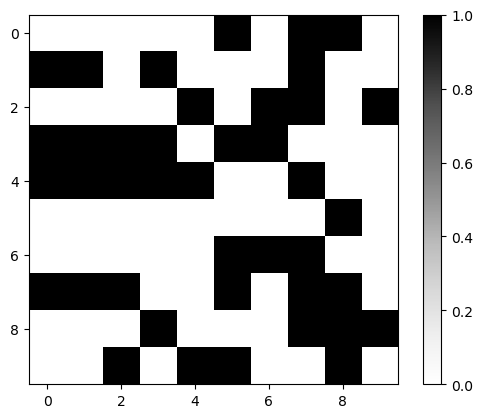

Volume Fraction Phase 0:
0.59
Volume Fraction Phase 1:
0.41


In [8]:
# Indicator function grids:
indicator_grids = []
for i in range(2):
    indicator_grids.append((phase_grid==i).astype(int))
    print(f"Indicator Phase {i}:")
    plot(indicator_grids[i])
    plt.show()

v = []
for i in range(2):
    v.append(np.sum(indicator_grids[i])/np.size(indicator_grids[i]))
    print(f"Volume Fraction Phase {i}:")
    print(v[i])

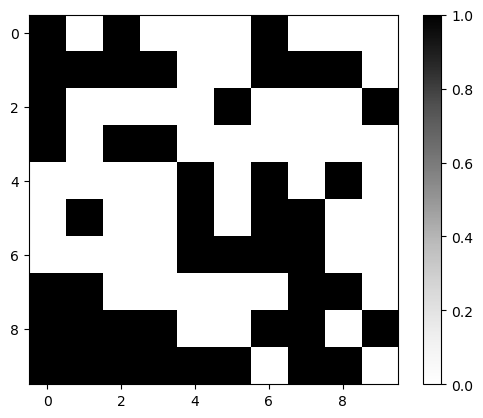

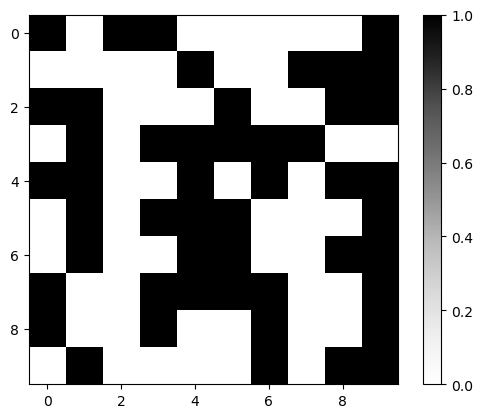

In [9]:
# Let's make an ensemble of it:
ensemble = []
for i in range(10):    
    rand_vector = np.random.randint(low=0, high=2, size=100)
    phase_grid = rand_vector.reshape((10, 10))
    ensemble.append(phase_grid)
plot(ensemble[0])
plt.show()
plot(ensemble[9])
plt.show()

In [10]:
# Which means we now need to calculate an indicator function ensemble... or just make it a function:
def indicator_grid(phase_grid, phase):
    return (phase_grid == phase).astype(int)

In [11]:
# One point correlation function:
def one_point_correlation_grid(ensemble, phase):
    result = np.zeros(ensemble[0].shape)
    for phase_grid in ensemble:
        result += indicator_grid(phase_grid, phase)
    result = result/len(ensemble)
    return result

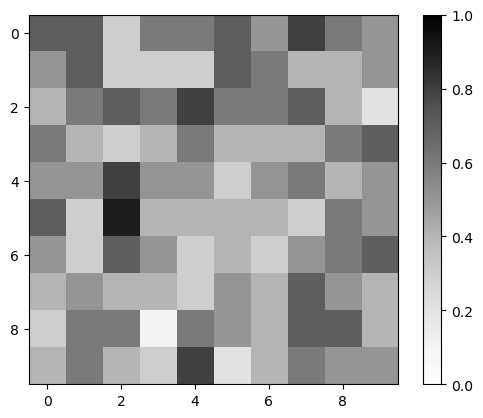

In [12]:
# Is the ensemble statistically homogeneous? Approximately... we might need more realizations.
one_point_correlation = one_point_correlation_grid(ensemble, 0)
plot(one_point_correlation)

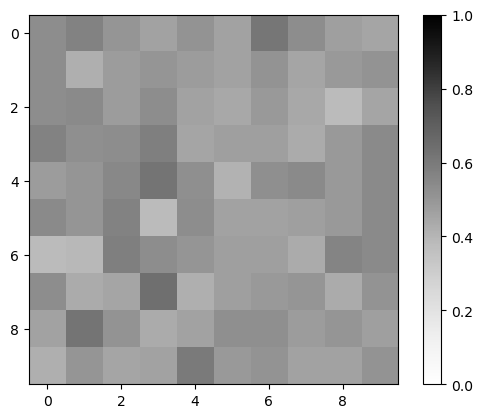

In [13]:
for i in range(90):    
    rand_vector = np.random.randint(low=0, high=2, size=100)
    phase_grid = rand_vector.reshape((10, 10))
    ensemble.append(phase_grid)
np.set_printoptions(linewidth=np.inf, precision=3)
plot(one_point_correlation_grid(ensemble, 0))
# good enough!

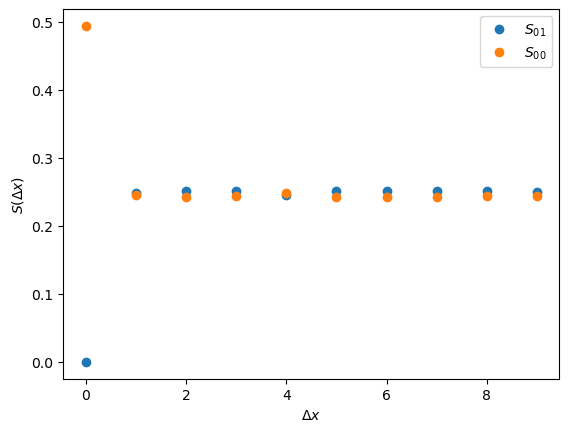

In [14]:
# Two-Point Correlation function in x_1 direction:
def correlation_grid(ensemble, phase1, phase2, x1, x2):
    result = np.zeros(ensemble[0].shape)
    for realization in ensemble:
        realization1 = np.roll(realization, x1)
        realization2 = np.roll(realization, x2)
        result += indicator_grid(realization1, phase1)*indicator_grid(realization2, phase2)
    result /= len(ensemble)
    return result
    
# statistically homogeneous:
def correlation(phase1, phase2, delta_x):
    grid = correlation_grid(ensemble, phase1, phase2, 0, delta_x)
    return np.sum(grid)/grid.size

dx = np.arange(10)
plt.plot(dx, [correlation(0, 1, dx_i) for dx_i in dx], "o", label="$S_{01}$")
plt.plot(dx, [correlation(0, 0, dx_i) for dx_i in dx], "o", label="$S_{00}$")
plt.legend()
plt.xlabel("$\Delta x$")
plt.ylabel("$S(\Delta x)$")
plt.show()
# it's not particularly interesting...

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]


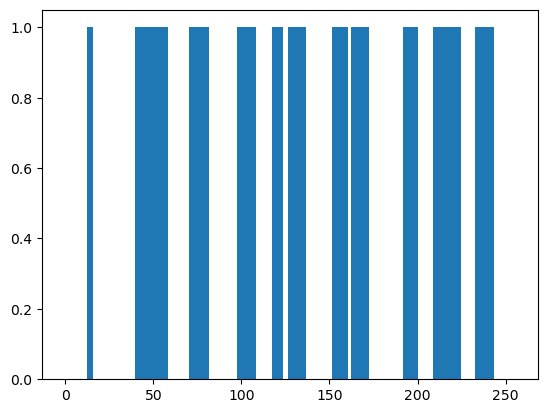

In [23]:
# Here's a real dataset: a 1D slice of a fibre composite microstructure
data_1 = np.loadtxt("data_1.txt", delimiter=" ", dtype=int)
print(data_1)
plt.bar(np.arange(len(data_1)), data_1, width=1)
plt.show()

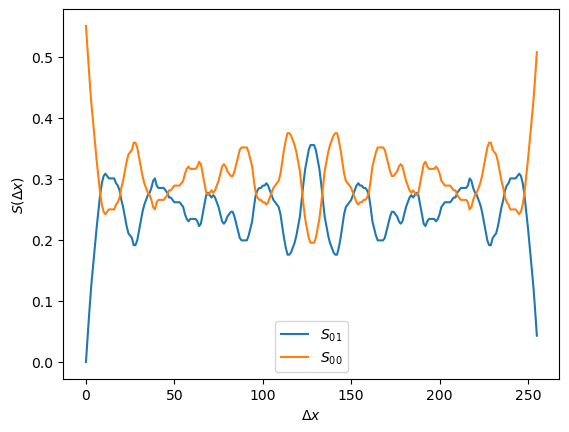

In [24]:
def cor(data, phase1, phase2, dx):
    ind1 = (data==phase1).astype(int)
    ind2 = (data==phase2).astype(int)
    return np.sum(ind1*(np.roll(ind2, dx)))/len(data)
dx = np.arange(len(data_1))
plt.plot(dx, [cor(data_1, 0, 1, dx_i) for dx_i in dx], label="$S_{01}$")
plt.plot(dx, [cor(data_1, 0, 0, dx_i) for dx_i in dx], label="$S_{00}$")
plt.legend()
plt.xlabel("$\Delta x$")
plt.ylabel("$S(\Delta x)$")
plt.show()

In [ ]:
# A minimal representation of the same data:
plt.plot(dx[:128], [cor(data_1, 0, 0, dx_i) for dx_i in dx[:128]], label="$S_{00}$")
plt.legend()
plt.xlabel("$\Delta x$")
plt.ylabel("$S(\Delta x)$")
plt.show()

In [ ]:
# and now, a fake dataset of equally spaced inclusions:
data_2 = np.array(([1,]*16+[0,]*16)*8)
print(data_2)
plt.bar(np.arange(len(data_2)), data_2, width=1)
plt.show()

In [ ]:
plt.plot(dx[:128], [cor(data_2, 0, 0, dx_i) for dx_i in dx[:128]], label="$S_{00}$")
plt.legend()
plt.xlabel("$\Delta x$")
plt.ylabel("$S(\Delta x)$")
plt.show()